# The TW Project

## Stage 1: Finetune a YOLO26s on LLVIP dataset

### Data preparation

In [2]:
"""Download the LLVIP dataset"""

import os


def download_llvip_dataset():
    import gdown

    url = "https://drive.google.com/uc?id=1VTlT3Y7e1h-Zsne4zahjx5q0TK2ClMVv"
    gdown.download(
        url=url,
        output="LLVIP.zip",
    )

if (not os.path.exists("LLVIP.zip")):
    print("Dataset not downloaded, now downloading")
    download_llvip_dataset()
else:
    import hashlib

    with open("LLVIP.zip", "rb") as f:
        file_hash = hashlib.md5()
        while chunk := f.read(8192):
            file_hash.update(chunk)
    if file_hash.hexdigest() != "e64affb4b0b50e1772ff6f67da873bf6":
        print("Download dataset again due to hash mismatch")
        download_llvip_dataset()

if (not os.path.exists("datasets")):
    os.makedirs("datasets")

if (not os.path.exists("datasets/LLVIP")):
    import zipfile
    
    with zipfile.ZipFile("LLVIP.zip", "r") as zip_ref:
        zip_ref.extractall("datasets")

In [7]:
"""Convert VOC format to YOLO format."""

from pathlib import Path
import xml.etree.ElementTree as ET
from tqdm.notebook import tqdm


base_path = Path("datasets/LLVIP").resolve()
SPLITS = {"train": 12025, "val": 3463}

def convert_box(size, box):
    dw, dh = 1.0 / size[0], 1.0 / size[1]
    x, y, w, h = (box[0] + box[1]) / 2.0 - 1, (box[2] + box[3]) / 2.0 - 1, box[1] - box[0], box[3] - box[2]
    return x * dw, y * dh, w * dw, h * dh

def convert_label(xml_path, lb_path):
    """Converts XML annotations from VOC format to YOLO format."""
    if not xml_path.exists():
        return
    with open(xml_path, "r", encoding="utf-8") as in_file, open(lb_path, "w", encoding="utf-8") as out_file:
        root = ET.parse(in_file).getroot()
        size = root.find("size")
        w, h = int(size.find("width").text), int(size.find("height").text)
        for obj in root.iter("object"):
            if obj.find("name").text == "person":
                xmlbox = obj.find("bndbox")
                bb = convert_box((w, h), [float(xmlbox.find(x).text) for x in ("xmin", "xmax", "ymin", "ymax")])
                out_file.write(f"0 {' '.join(str(a) for a in bb)}\n")

def process_split(split, source_subdir, expected_count):
    for folder in ["images", "labels"]:
        (base_path / folder / split).mkdir(parents=True, exist_ok=True)

    images = sorted((base_path / "infrared" / source_subdir).glob("*.jpg"))
    assert len(images) == expected_count

    for img_path in tqdm(images, desc=f"Processing {split} split"):
        (base_path / "images" / split / img_path.name).parent.mkdir(parents=True, exist_ok=True)
        img_path.rename(base_path / "images" / split / img_path.name)
        convert_label(
            base_path / "Annotations" / img_path.with_suffix(".xml").name,
            base_path / "labels" / split / img_path.with_suffix(".txt").name,
        )

process_split("train", "train", SPLITS["train"])
process_split("val", "test", SPLITS["val"])  # test set used as val

AssertionError: 

In [8]:
"""Create dataset YAML file"""

yaml_path = base_path / "llvip.yaml"
yaml_content = f"""path: {base_path}
train: {base_path / 'images' / 'train'}
val: {base_path / 'images' / 'val'}
nc: 1
names: ['person']
"""

yaml_path.write_text(yaml_content, encoding="utf-8")

168

### Tuning and training

In [9]:
from pathlib import Path
from ultralytics import YOLO
from ultralytics.models.yolo.detect import DetectionTrainer


class CustomSaveTrainer(DetectionTrainer):
    """Trainer that saves the best model based on recall instead of default fitness."""

    def validate(self):
        """Override fitness to use recall for best model selection."""
        metrics, fitness = super().validate()
        if metrics:
            recall  = metrics.get("metrics/recall(B)", 0.0)
            map50   = metrics.get("metrics/mAP50(B)", 0.0)
            map5095 = metrics.get("metrics/mAP50-95(B)", 0.0)

            fitness = (0.60 * recall) + (0.30 * map5095) + (0.10 * map50)

            if self.best_fitness is None or fitness > self.best_fitness:
                self.best_fitness = fitness
        return metrics, fitness


yaml_path = Path("datasets/LLVIP/llvip.yaml").resolve()

In [ ]:
"""Train YOLO26n"""

from ultralytics import YOLO


model = YOLO("yolo26n.pt")
model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=64,
    optimizer="MuSGD",
    lr0=0.0054,
    lrf=0.0495,
    momentum=0.947,
    weight_decay=0.00064,
    warmup_epochs=0.98,
    name="llvip_yolo26n_rc_2",
    cache='disk',
    # freeze=10,
    patience=20,
    trainer=CustomSaveTrainer,
    exist_ok=True,
    device="cuda:1",
    workers=16,
    close_mosaic=15,
    # Augmentation
    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.2,
    degrees=0.0,
    translate=0.1,
    scale=0.4,
    shear=0.0,
    flipud=0.0,
    fliplr=0.5,
    mosaic=0.2,
    mixup=0.0,
    erasing=0.2,
)

New https://pypi.org/project/ultralytics/8.4.51 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.46 🚀 Python-3.13.13 torch-2.12.0+rocm7.2 CUDA:1 (AMD Radeon Graphics, 16368MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/w/tw_project/datasets/LLVIP/llvip.yaml, degrees=0.0, deterministic=True, device=1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.2, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.2, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0054, lrf=0.0495, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.947, mosaic=0.2

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f29d456c210>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

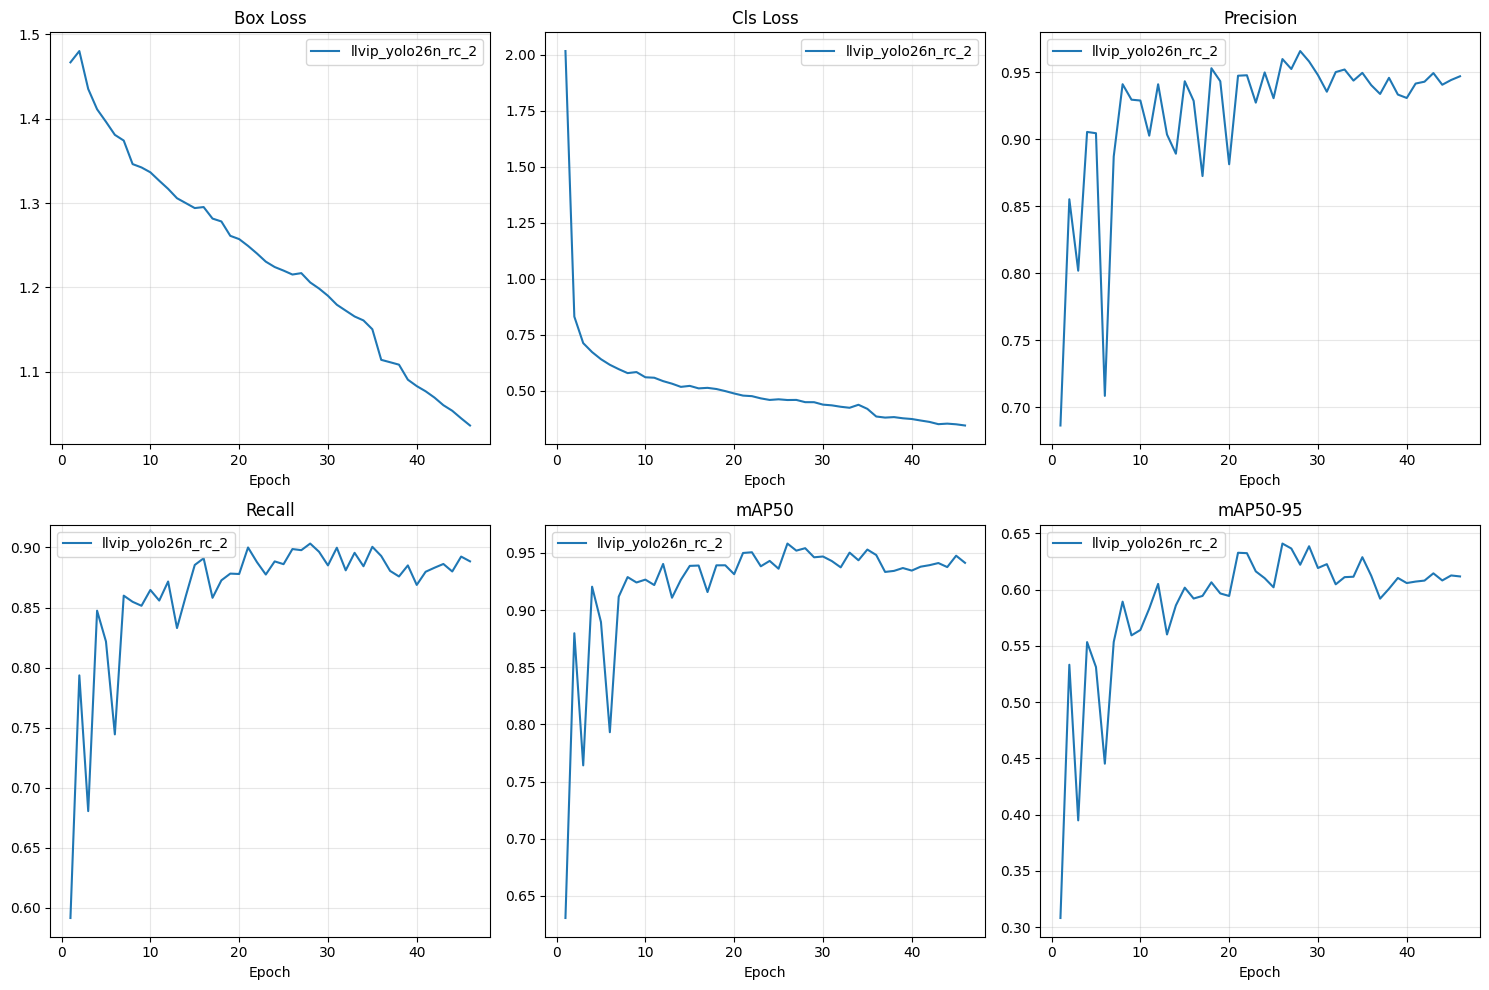

In [11]:
"""View training metrics"""

%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def plot_training_metrics(*run_dirs, figsize=(15, 10)):
    metrics = [
        ("train/box_loss",  "Box Loss"),
        ("train/cls_loss",  "Cls Loss"),
        ("metrics/precision(B)", "Precision"),
        ("metrics/recall(B)",    "Recall"),
        ("metrics/mAP50(B)",     "mAP50"),
        ("metrics/mAP50-95(B)",  "mAP50-95"),
    ]
    
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.flatten()
    
    for run_dir in run_dirs:
        csv_path = Path(run_dir) / "results.csv"
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()
        label = Path(run_dir).name
        
        for ax, (col, title) in zip(axes, metrics):
            if col in df.columns:
                ax.plot(df["epoch"], df[col], label=label)
                ax.set_title(title)
                ax.set_xlabel("Epoch")
                ax.legend()
                ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


plot_training_metrics(
    "runs/detect/llvip_yolo26n_rc_2",
)

## Model export and deployment

In [13]:
from ultralytics import YOLO
from pathlib import Path

model = YOLO("runs/detect/llvip_yolo26n_rc_2/weights/best.pt")
model.export(
    format="onnx",
    imgsz=640,
    name="llvip_yolo26n_rc_2"
)

Ultralytics 8.4.46 🚀 Python-3.13.13 torch-2.12.0+rocm7.2 CPU (AMD Ryzen 5 5600G with Radeon Graphics)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from 'runs/detect/llvip_yolo26n_rc_2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.1 MB)
requirements: Ultralytics requirement ['onnxruntime-gpu'] not found, attempting AutoUpdate...
Resolved 5 packages in 400ms
Prepared 1 package in 17.27s
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 1 package in 333ms
 + onnxruntime-gpu==1.26.0

requirements: AutoUpdate success ✅ 18.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.93...


/home/w/tw_project/.venv/lib/python3.13/site-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: export success ✅ 19.0s, saved as 'runs/detect/llvip_yolo26n_rc_2/weights/best.onnx' (9.4 MB)

Export complete (19.4s)
Results saved to /home/w/tw_project/runs/detect/llvip_yolo26n_rc_2/weights/best.onnx
Predict:         yolo predict task=detect model=runs/detect/llvip_yolo26n_rc_2/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=runs/detect/llvip_yolo26n_rc_2/weights/best.onnx imgsz=640 data=/home/w/tw_project/datasets/LLVIP/llvip.yaml  
Visualize:       https://netron.app


'runs/detect/llvip_yolo26n_rc_2/weights/best.onnx'

In [14]:
"""Run val"""

from ultralytics import YOLO
from pathlib import Path

model = YOLO("runs/detect/llvip_yolo26n_rc_2/weights/best.onnx")
metrics = model.val(
    data=Path("datasets/LLVIP/llvip.yaml").resolve(),
    name="llvip_val_results",
    batch=256,
    imgsz=640,
    device="cpu",
    exist_ok=True,
    # visualize=True,
)

Ultralytics 8.4.46 🚀 Python-3.13.13 torch-2.12.0+rocm7.2 CPU (AMD Ryzen 5 5600G with Radeon Graphics)
Loading runs/detect/llvip_yolo26n_rc_2/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.26.0 with CPUExecutionProvider
Setting batch=1 input of shape (1, 3, 640, 640)
val: Fast image access ✅ (ping: 0.2±0.1 ms, read: 308.8±112.7 MB/s, size: 68.6 KB)
val: Scanning /home/w/tw_project/datasets/LLVIP/labels/val.cache... 3463 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3463/3463 1.8Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3463/3463 29.2it/s 1:58<0.1ss
                   all       3463       8302      0.968      0.894      0.958      0.638
Speed: 5.9ms preprocess, 21.4ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /home/w/tw_project/runs/detect/llvip_val_results
